In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings("ignore")


In [ ]:
df = pd.read_csv(r'"C:\Users\pinku\Desktop\deploy\banglore_house.ipynb"')

# View basic info
df.head()


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
# Shape and columns
print("Shape:", df.shape)


Shape: (13320, 9)


In [4]:
df['price'].value_counts()

price
75.00    310
65.00    302
55.00    275
60.00    270
45.00    240
        ... 
43.04      1
61.11      1
46.56      1
42.54      1
47.35      1
Name: count, Length: 1994, dtype: int64

In [5]:
# let's check each columns value counts
for columns in df.columns:
    print(df[columns].value_counts())
    print("****" * 10)

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64
****************************************
availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
                 ...  
16-Oct               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64
****************************************
location
Whitefield                         540
Sarjapur  Road                     399
Electronic City                    302
Kanakpura Road                     273
Thanisandra                        234
                                  ... 
3rd Stage Raja Rajeshwari Nagar      1
Chuchangatta Colony                  1
Electronic City Phase 1,             1
Chikbasavanapura                     1
Abshot Layout                        1
Name: count, Length: 130

In [6]:
print("\nColumns:", df.columns)


Columns: Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [8]:
# Drop these features (too many missing or irrelevant)
df = df.drop(['area_type','society','balcony','availability'], axis='columns')
df.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [9]:
df.isnull().sum()


location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [10]:
df = df.dropna()


In [11]:
# Convert 'size' to numeric (e.g., '2 BHK' → 2)
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]))
df['bhk']

0        2
1        4
2        3
3        3
4        2
        ..
13315    5
13316    4
13317    2
13318    4
13319    1
Name: bhk, Length: 13246, dtype: int64

In [12]:
# Top 10 location in banglore where pilot and flat sele
df['location'].value_counts().head(10)

location
Whitefield               534
Sarjapur  Road           392
Electronic City          302
Kanakpura Road           266
Thanisandra              233
Yelahanka                210
Uttarahalli              186
Hebbal                   176
Marathahalli             175
Raja Rajeshwari Nagar    171
Name: count, dtype: int64

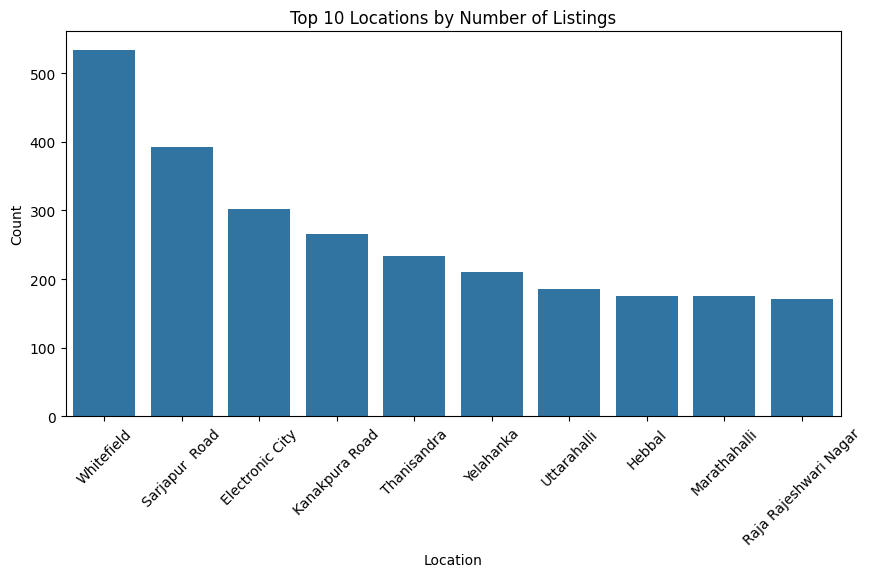

In [13]:
# 🟢 Top 10 locations with most listings
top_locations = df['location'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_locations.index, y=top_locations.values)
plt.xticks(rotation=45)
plt.title('Top 10 Locations by Number of Listings')
plt.xlabel('Location')
plt.ylabel('Count')
plt.show()

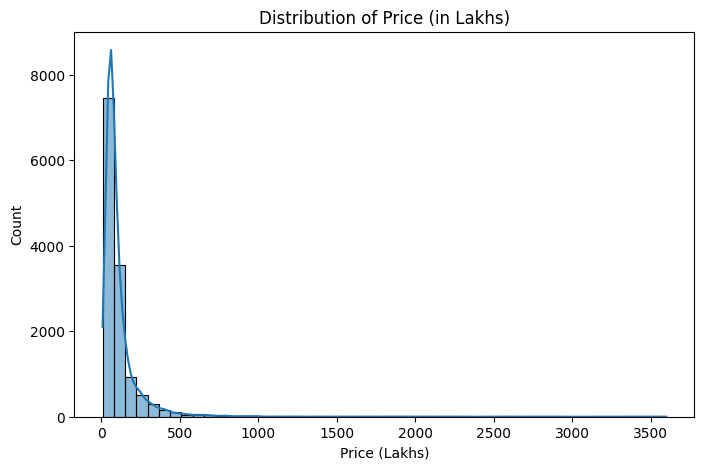

In [14]:
# 🟦 Distribution of price
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Price (in Lakhs)')
plt.xlabel('Price (Lakhs)')
plt.ylabel('Count')
plt.show()

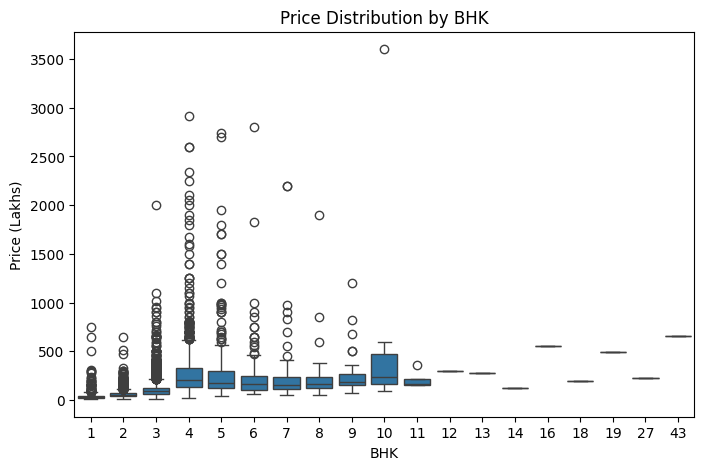

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='bhk', y='price', data=df)
plt.title('Price Distribution by BHK')
plt.xlabel('BHK')
plt.ylabel('Price (Lakhs)')
plt.show()



Index(['location', 'size', 'total_sqft', 'bath', 'price', 'bhk'], dtype='object')


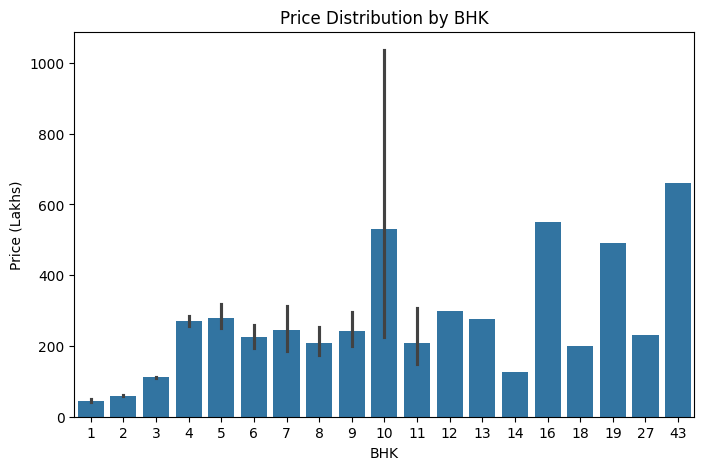

In [16]:
print(df.columns) # Explicitly print columns to verify
plt.figure(figsize=(8, 5))
sns.barplot(x='bhk', y='price', data=df.copy()) # Pass a copy to ensure fresh data
plt.title('Price Distribution by BHK')
plt.xlabel('BHK')
plt.ylabel('Price (Lakhs)')
plt.show()

# 🛠️ Feature Engineering and Data Cleaning

In [17]:
# 📏 Converting 'total_sqft' to Numeric Format¶
# Convert 'total_sqft' to a single numeric value
def convert_sqft_to_num(x):
    try:
        x = str(x)
        tokens = x.split('-')
        if len(tokens) == 2:
            return (float(tokens[0]) + float(tokens[1])) / 2
        return float(x)
    except:
        return None

In [18]:
df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)

df['total_sqft']

0        1056.0
1        2600.0
2        1440.0
3        1521.0
4        1200.0
          ...  
13315    3453.0
13316    3600.0
13317    1141.0
13318    4689.0
13319     550.0
Name: total_sqft, Length: 13246, dtype: float64

In [19]:

# Drop rows with invalid or null 'total_sqft'
df = df.dropna(subset=['total_sqft'])

print("After sqft conversion:", df.shape)

After sqft conversion: (13200, 6)


In [20]:

df.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,51.00,2


In [21]:
# 💰 Calculating Price per Square Foot¶
# Add new column: price per square foot
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']

#Price = 50 (lakhs) → ₹50 × 100,000 = ₹5,000,000

#Total Sqft = 1000


# price_per_sqft = 5,000,000 / 1000 = ₹5000 per sqft

Cleaning and Grouping Location Data


In [22]:
# Clean 'location' text
df['location'] = df['location'].apply(lambda x: x.strip())
df['location']


0        Electronic City Phase II
1                Chikka Tirupathi
2                     Uttarahalli
3              Lingadheeranahalli
4                        Kothanur
                   ...           
13315                  Whitefield
13316               Richards Town
13317       Raja Rajeshwari Nagar
13318             Padmanabhanagar
13319                Doddathoguru
Name: location, Length: 13200, dtype: object

In [23]:
# Group rare locations as 'other'
location_counts = df['location'].value_counts()
location_counts

location
Whitefield                           533
Sarjapur  Road                       392
Electronic City                      304
Kanakpura Road                       264
Thanisandra                          235
                                    ... 
Zuzuvadi                               1
Chellikere                             1
Jakkasandra                            1
Gulakamale                             1
Beml layout, Rajarajeshwari nagar      1
Name: count, Length: 1287, dtype: int64

In [24]:
rare_locations = location_counts[location_counts <= 10].index
rare_locations

Index(['Ganga Nagar', 'Kalkere', 'Dairy Circle', '1st Block Koramangala',
       'Sector 1 HSR Layout', 'Basapura', 'Gunjur Palya', 'BTM 1st Stage',
       'Nagadevanahalli', 'Sadashiva Nagar',
       ...
       '3rd Stage Raja Rajeshwari Nagar', 'Mallappa Layout', 'Sindhi Colony',
       'Masjid e Alkareem', 'Kanakapura main  Road', 'Zuzuvadi', 'Chellikere',
       'Jakkasandra', 'Gulakamale', 'Beml layout, Rajarajeshwari nagar'],
      dtype='object', name='location', length=1047)

In [25]:
df['location'] = df['location'].apply(lambda x: 'other' if x in rare_locations else x)

df['location'].unique()

array(['Electronic City Phase II', 'Chikka Tirupathi', 'Uttarahalli',
       'Lingadheeranahalli', 'Kothanur', 'Whitefield', 'Old Airport Road',
       'Rajaji Nagar', 'Marathahalli', 'other', '7th Phase JP Nagar',
       'Gottigere', 'Sarjapur', 'Mysore Road', 'Bisuvanahalli',
       'Raja Rajeshwari Nagar', 'Kengeri', 'Binny Pete', 'Thanisandra',
       'Bellandur', 'Electronic City', 'Ramagondanahalli', 'Yelahanka',
       'Hebbal', 'Kasturi Nagar', 'Kanakpura Road',
       'Electronics City Phase 1', 'Kundalahalli', 'Chikkalasandra',
       'Murugeshpalya', 'Sarjapur  Road', 'HSR Layout', 'Doddathoguru',
       'KR Puram', 'Bhoganhalli', 'Lakshminarayana Pura', 'Begur Road',
       'Varthur', 'Bommanahalli', 'Gunjur', 'Devarachikkanahalli',
       'Hegde Nagar', 'Haralur Road', 'Hennur Road', 'Kothannur',
       'Kalena Agrahara', 'Kaval Byrasandra', 'ISRO Layout',
       'Garudachar Palya', 'EPIP Zone', 'Dasanapura', 'Kasavanhalli',
       'Sanjay nagar', 'Domlur', 'Sarjapura - At

In [26]:
print("Unique locations:", len(df['location'].unique()))

Unique locations: 241


# Removing Unrealistically Small BHK Configurations

In [27]:
# Remove rows where total_sqft per BHK is less than 300
df = df[df['total_sqft'] / df['bhk'] >= 300]

print("After removing low sqft per BHK:", df.shape)

# In real-world housing, a livable bedroom typically needs at least 300 sqft for comfort, furniture, walking space, and basic design.

# So if a house says:

# It has 3 BHK (3 bedrooms),

# But total square feet is only 600 sqft,

# 600 / 3 = 200 sqft per bedroom
# That’s too cramped to be realistic or useful.

After removing low sqft per BHK: (12456, 7)


# Removing Location-Wise Price per Sqft Outliers

In [28]:
# This function removes price_per_sqft outliers location-wise
def remove_pps_outliers(df):
    cleaned_df = pd.DataFrame()  # Empty DataFrame to store clean data

    # Group data by each location
    for location, group in df.groupby('location'):
        mean = group['price_per_sqft'].mean()
        std = group['price_per_sqft'].std()

        # Keep only rows where price_per_sqft is within one std deviation from mean
        filtered = group[(group['price_per_sqft'] > (mean - std)) &
                         (group['price_per_sqft'] <= (mean + std))]

        cleaned_df = pd.concat([cleaned_df, filtered], ignore_index=True)

    return cleaned_df

# Apply the function to clean the dataset
df = remove_pps_outliers(df)

print("✅ After removing price_per_sqft outliers:", df.shape)

# 🧹 Remove price_per_sqft outliers for each location
# Example: In a location like Indira Nagar, most properties sell for ₹10,000–₹15,000 per sqft.
# But a luxury penthouse listed at ₹30,000/sqft or a distress sale at ₹5,000/sqft will distort the average.
# So for each location, we only keep the listings within 1 standard deviation of the average price/sqft.
# This removes extreme values and helps our model learn from typical property prices in that area.

✅ After removing price_per_sqft outliers: (10293, 7)


# 🏠 Removing BHK-Based Pricing Outliers¶


In [29]:
# This function removes BHK-based pricing outliers for each location
def remove_bhk_outliers(df):
    indices_to_remove = []  # Store indexes of outliers

    # Group data by each location
    for location, location_df in df.groupby('location'):
        # Create a dictionary to store price stats for each BHK level
        bhk_price_stats = {}

        # Loop through each BHK group in that location
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_price_stats[bhk] = {
                'mean_price': bhk_df['price_per_sqft'].mean(),
                'std_dev': bhk_df['price_per_sqft'].std(),
                'count': bhk_df.shape[0]
            }

        # Now check if a higher BHK is priced less than the lower BHK's average
        for bhk, bhk_df in location_df.groupby('bhk'):
            lower_bhk_stats = bhk_price_stats.get(bhk - 1)
            if lower_bhk_stats and lower_bhk_stats['count'] > 5:
                # If this BHK is priced less than the previous BHK's average → outlier
                bad_bhk = bhk_df[bhk_df['price_per_sqft'] < lower_bhk_stats['mean_price']]
                indices_to_remove.extend(bad_bhk.index)

    # Drop all detected outliers
    return df.drop(indices_to_remove, axis='index')

# Apply the function
df = remove_bhk_outliers(df)

print("✅ After removing BHK outliers:", df.shape)


# 🧹 Remove BHK outliers based on pricing logic
# Example: In the same location (e.g., Indira Nagar), a 3 BHK should logically cost more per sqft than a 2 BHK.
# But if a 3 BHK is selling for less than the average price/sqft of 2 BHKs nearby, it's suspicious — maybe poorly built or wrongly entered.
# So we remove such cases where a bigger BHK is cheaper per sqft than the smaller one (if the smaller BHK has enough data, i.e., > 5 samples).
# This keeps our training data clean and realistic for the model.


✅ After removing BHK outliers: (7365, 7)


# Removing Unrealistic Bathroom Counts¶


In [30]:
# Keep rows where number of bathrooms is reasonable
df = df[df['bath'] < df['bhk'] + 2]

print("After removing bathroom outliers:", df.shape)

After removing bathroom outliers: (7286, 7)


# Dropping Unnecessary Columns for Modeling

In [31]:
# Drop unused columns
df_model = df.drop(['size', 'price_per_sqft'], axis=1)
df_model.head()

,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,2850.0,4.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,194.0,3
2,1st Block Jayanagar,1875.0,2.0,235.0,3
3,1st Block Jayanagar,1200.0,2.0,130.0,3
4,1st Block Jayanagar,1235.0,2.0,148.0,2


In [32]:
# One-Hot Encode Location Col

In [33]:
df['location'].unique()

array(['1st Block Jayanagar', '1st Phase JP Nagar',
       '2nd Phase Judicial Layout', '2nd Stage Nagarbhavi',
       '5th Block Hbr Layout', '5th Phase JP Nagar', '6th Phase JP Nagar',
       '7th Phase JP Nagar', '8th Phase JP Nagar', '9th Phase JP Nagar',
       'AECS Layout', 'Abbigere', 'Akshaya Nagar', 'Ambalipura',
       'Ambedkar Nagar', 'Amruthahalli', 'Anandapura', 'Ananth Nagar',
       'Anekal', 'Anjanapura', 'Ardendale', 'Arekere', 'Attibele',
       'BEML Layout', 'BTM 2nd Stage', 'BTM Layout', 'Babusapalaya',
       'Badavala Nagar', 'Balagere', 'Banashankari',
       'Banashankari Stage II', 'Banashankari Stage III',
       'Banashankari Stage V', 'Banashankari Stage VI', 'Banaswadi',
       'Banjara Layout', 'Bannerghatta', 'Bannerghatta Road',
       'Basavangudi', 'Basaveshwara Nagar', 'Battarahalli', 'Begur',
       'Begur Road', 'Bellandur', 'Benson Town', 'Bharathi Nagar',
       'Bhoganhalli', 'Billekahalli', 'Binny Pete', 'Bisuvanahalli',
       'Bommanahalli'

In [34]:
# Create dummy variables (one-hot encoding) for location
dummies = pd.get_dummies(df_model['location'], dtype=int)
df_model = pd.concat([df_model.drop('location', axis=1), dummies.drop('other', axis=1)], axis=1)


print("Final shape after encoding:", df_model.shape)

Final shape after encoding: (7286, 244)


In [35]:
df_model.head()

,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.0,4.0,428.0,4,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1630.0,3.0,194.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1875.0,2.0,235.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1200.0,2.0,130.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1235.0,2.0,148.0,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Train Test Split

In [36]:
# Split features and label
X = df_model.drop('price', axis=1)
y = df_model['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5828, 243)
X_test shape: (1458, 243)


In [37]:
# Linear Regression
# Train a Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Evaluate on test set
y_pred = lr_model.predict(X_test)
lr_r2 = r2_score(y_test, y_pred)

print("📉 Linear Regression R² Score:", round(lr_r2, 3))

📉 Linear Regression R² Score: 0.855


In [38]:
# RandomForest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Train a Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate on test set
y_pred_rf = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, y_pred_rf)

print("🌲 Random Forest R² Score:", round(rf_r2, 3))


🌲 Random Forest R² Score: 0.84


In [39]:
# XGBoost Regressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# Train an XGBoost model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Evaluate on test set
y_pred_xgb = xgb_model.predict(X_test)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("🚀 XGBoost R² Score:", round(xgb_r2, 3))

🚀 XGBoost R² Score: 0.859


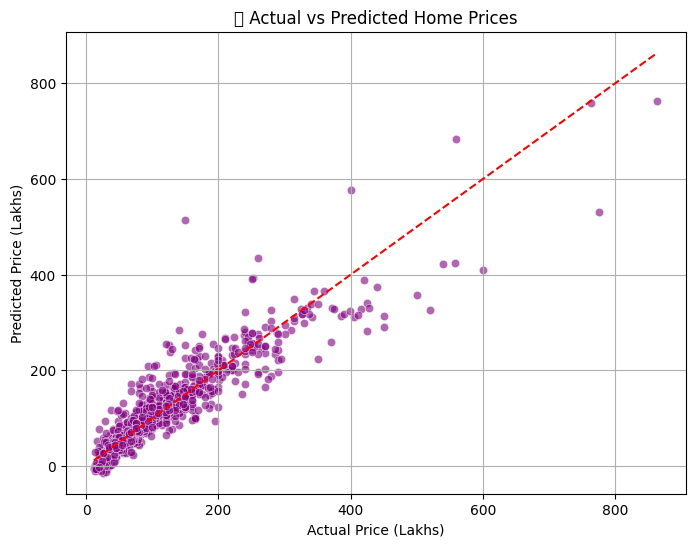

In [40]:
# Scatter plot of Actual vs Predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')  # Diagonal line
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title('🔍 Actual vs Predicted Home Prices')
plt.grid(True)
plt.show()

In [41]:
# Saving The Model



import joblib

# Save the model
joblib.dump(lr_model, 'linear_regression_model.pkl')

# Load the model
# loaded_model = joblib.load('linear_regression_model.pkl')




['linear_regression_model.pkl']

In [42]:
from sklearn.linear_model import Ridge, Lasso

In [43]:
# Train a Ridge Regression model
ridge_model = Ridge(alpha=1.0) # You can tune the alpha parameter
ridge_model.fit(X_train, y_train)

# Evaluate on test set
y_pred_ridge = ridge_model.predict(X_test)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("⛰️ Ridge Regression R² Score:", round(ridge_r2, 3))

⛰️ Ridge Regression R² Score: 0.856


In [44]:


# Train a Lasso Regression model
lasso_model = Lasso(alpha=0.1) # You can tune the alpha parameter
lasso_model.fit(X_train, y_train)

# Evaluate on test set
y_pred_lasso = lasso_model.predict(X_test)
lasso_r2 = r2_score(y_test, y_pred_lasso)

print("🔗 Lasso Regression R² Score:", round(lasso_r2, 3))

🔗 Lasso Regression R² Score: 0.821


In [45]:
import joblib

# Save the XGBoost model
joblib.dump(xgb_model, 'xgboost_model.pkl')

print("XGBoost model saved successfully to 'xgboost_model.pkl'")

XGBoost model saved successfully to 'xgboost_model.pkl'
